### Libraries

In [1]:
import json
import random
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [2]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) # Set the seed for the current GPU
    torch.cuda.manual_seed_all(seed) # Set the seed for all GPUs (if you are using multi-GPU).
    
# Set deterministic behavior for CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for additional determinism
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_path = "../huggingface_cache"
cache_dir = Path(cache_path)
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


In [4]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [5]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [6]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [7]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 70:15:15


Once a set has been chosen, continue with next steps

In [8]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
0    0.5
1    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [9]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (16014, 2) {0: 8007, 1: 8007}
val: (3432, 2) {0: 1716, 1: 1716}
test: (3432, 2) {0: 1716, 1: 1716}


In [10]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (1221 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 188952), ('i', 48102), ('you', 35395), ('the', 27098), ('to', 21198), ('it', 17595), ('a', 17394), ('me', 15901), ('and', 15583), ('not', 13684)]


In [11]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 12
sample ids: [2054, 2057, 2113, 1010, 2073, 2017, 4618, 2175, 1010, 2373, 1010, 6289, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label

### Hyperparameter Tuning with Optuna

We'll search for the best hyperparameters using Optuna, which efficiently explores different combinations and focuses on promising regions. We'll tune:
- Learning rate (1e-4 to 1e-3)
- Embedding dimension (64, 128, 256)
- Hidden dimension (128, 256, 512)
- Number of layers (1, 2, 3)
- Dropout rate (0.1 to 0.5)
- Batch size (16, 32, 64)

In [13]:
# Define the LSTM model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)

In [14]:
# Run one epoch of training or evaluation
def run_epoch(model, loader: DataLoader, criterion, optimizer=None, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())
        
        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions

In [15]:
# Create a seeded generator for the DataLoader
g = torch.Generator()
g.manual_seed(42)

In [16]:
import optuna
from optuna.pruners import MedianPruner

def objective(trial: optuna.Trial):
    # Set the random seed for reproducibility
    g.manual_seed(42)

    # Suggest hyperparameters
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data loaders with the suggested batch size
    # train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
    train_loader = DataLoader(
        LyricsDataset(train_df), 
        batch_size=batch_size, 
        shuffle=True,
        generator=g,           
        num_workers=0          # for reproducibility
    )
    val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False, num_workers=0)

    # Initialize model with suggested hyperparameters
    model = LSTMClassifier(
        vocab_size=len(tokenizer),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train for a few epochs with Early Stopping
    num_epochs = 10
    best_val_loss = float("inf")
    patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, criterion, training=False)

        print(f"  Trial {trial.number}, Epoch {epoch + 1}/{num_epochs}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        # Early Stopping Logic (Patience = 3)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter when loss improves
        else:
            patience_counter += 1  # Increment patience counter when loss doesn't improve

        # Prune trial if validation loss is not improving (MedianPruner)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stop if patience is exceeded
        if patience_counter >= patience:
            print(f"  Early stopping triggered! No improvement for {patience} epochs.")
            break

    return best_val_loss

In [17]:
# For reproducibility, set a fixed seed for the TPE sampler
sampler = optuna.samplers.TPESampler(seed=42)

In [18]:
# Create a study and run the hyperparameter search
study = optuna.create_study(
    direction="minimize",  # Minimize validation loss
    sampler=sampler,
    pruner=MedianPruner(),
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-13 12:45:29,459] A new study created in memory with name: no-name-2cf3e3f8-7cca-408f-8590-676ec933194b
  0%|          | 0/20 [00:00<?, ?it/s]

  Trial 0, Epoch 1/10: val_loss=0.6830, val_acc=0.5484
  Trial 0, Epoch 2/10: val_loss=0.5498, val_acc=0.7159
  Trial 0, Epoch 3/10: val_loss=0.4938, val_acc=0.7622
  Trial 0, Epoch 4/10: val_loss=0.4388, val_acc=0.7931
  Trial 0, Epoch 5/10: val_loss=0.4274, val_acc=0.7920
  Trial 0, Epoch 6/10: val_loss=0.4269, val_acc=0.8074
  Trial 0, Epoch 7/10: val_loss=0.4527, val_acc=0.8048
  Trial 0, Epoch 8/10: val_loss=0.4557, val_acc=0.8191


  0%|          | 0/20 [27:43<?, ?it/s]

  Trial 0, Epoch 9/10: val_loss=0.4757, val_acc=0.8045
  Early stopping triggered! No improvement for 3 epochs.
[I 2026-08-13 13:13:13,157] Trial 0 finished with value: 0.42693334140560846 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'batch_size': 16}. Best is trial 0 with value: 0.42693334140560846.


Best trial: 0. Best value: 0.426933:   5%|▌         | 1/20 [27:43<8:46:52, 1663.83s/it]

...

  Trial 17, Epoch 1/10: val_loss=0.6041, val_acc=0.6763
[I 2026-08-13 14:06:04,248] Trial 17 pruned. 
  Trial 18, Epoch 1/10: val_loss=0.5838, val_acc=0.7098


Best trial: 16. Best value: 0.409295:  95%|█████████▌| 19/20 [1:21:53<02:10, 130.25s/it]

  Trial 18, Epoch 2/10: val_loss=0.5953, val_acc=0.6871
[I 2026-08-13 14:07:22,979] Trial 18 pruned. 


Best trial: 16. Best value: 0.409295: 100%|██████████| 20/20 [1:22:41<00:00, 248.10s/it]

  Trial 19, Epoch 1/10: val_loss=0.6057, val_acc=0.6795
[I 2026-08-13 14:08:11,414] Trial 19 pruned. 


In [19]:
# Print best trial results
best_trial = study.best_trial

print(f"Best validation loss: {best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best validation loss: 0.4093
Best hyperparameters:
  learning_rate: 0.0005
  embedding_dim: 256
  hidden_dim: 512
  num_layers: 2
  dropout: 0.1
  batch_size: 32


In [20]:
# Reset seeds before final model creation
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
random.seed(42)
np.random.seed(42)

# Create fresh generator
g_final = torch.Generator() # Use g_final in DataLoaders instead of g
g_final.manual_seed(42)

### Final Training with Best Hyperparameters

Train the final model using the best hyperparameters found by Optuna on the full train set, and evaluate on the test set.

In [21]:
# Extract best hyperparameters
best_params = best_trial.params
best_learning_rate = best_params["learning_rate"]
best_embedding_dim = best_params["embedding_dim"]
best_hidden_dim = best_params["hidden_dim"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_batch_size = best_params["batch_size"]

# Create data loaders with best batch size
train_loader = DataLoader(LyricsDataset(train_df), batch_size=best_batch_size, shuffle=True, generator=g_final, num_workers=0)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)

# Initialize final model with best hyperparameters
model = LSTMClassifier(
    vocab_size=len(tokenizer),
    embedding_dim=best_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers,
    dropout=best_dropout,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_learning_rate)

print("Final model architecture:")
print(model)

Final model architecture:
LSTMClassifier(
  (embedding): Embedding(30522, 256, padding_idx=0)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=1024, out_features=1, bias=True)
)


In [22]:
# Train the final model with best hyperparameters

num_epochs = 10
best_val_loss = float("inf")
best_model_path = Path("lstm_lyrics_classifier.pt")
history = []

# Add patience variables for early stopping
patience = 3
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_targets, train_probs, train_predictions = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss, val_acc, val_targets, val_probs, val_predictions = run_epoch(model, val_loader, criterion, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    # Check if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # Reset patience counter when loss improves
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1  # Increment patience counter when loss doesn't improve
    
    # Early stopping logic - break if patience is exceeded
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} consecutive epochs.")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break
    
history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6434 train_acc=0.6288 | val_loss=0.5908 val_acc=0.6900
Epoch 02 | train_loss=0.5382 train_acc=0.7219 | val_loss=0.4828 val_acc=0.7573
Epoch 03 | train_loss=0.4233 train_acc=0.8006 | val_loss=0.4924 val_acc=0.7794
Epoch 04 | train_loss=0.4100 train_acc=0.8137 | val_loss=0.4324 val_acc=0.8027
Epoch 05 | train_loss=0.3413 train_acc=0.8536 | val_loss=0.3891 val_acc=0.8202
Epoch 06 | train_loss=0.2694 train_acc=0.8898 | val_loss=0.4429 val_acc=0.8132
Epoch 07 | train_loss=0.2134 train_acc=0.9162 | val_loss=0.4013 val_acc=0.8333
Epoch 08 | train_loss=0.1554 train_acc=0.9412 | val_loss=0.4729 val_acc=0.8269

Early stopping triggered! No improvement for 3 consecutive epochs.
Best validation loss: 0.3891


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.643428,0.628825,0.590795,0.689977
1,2,0.538185,0.721931,0.482785,0.757284
2,3,0.423342,0.800612,0.492406,0.779429
3,4,0.410009,0.813663,0.432361,0.802739
4,5,0.341280,0.853566,0.389105,0.820221
5,6,0.269449,0.889846,0.442891,0.813228
6,7,0.213425,0.916198,0.401335,0.833333
7,8,0.155364,0.941239,0.472883,0.826923


### Model Evaluation

In [23]:
# Load best checkpoint and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(model, test_loader, criterion, training=False)

#### Classification Report

In [32]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"LSTM CLASSIFICATION REPORT (TUNING - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

LSTM CLASSIFICATION REPORT (TUNING - 70:15:15):
Accuracy: 0.8041958041958042
Precision: 0.82625
Recall: 0.7703962703962703
F1-score: 0.7973462002412546


#### ROC-AUC Curve

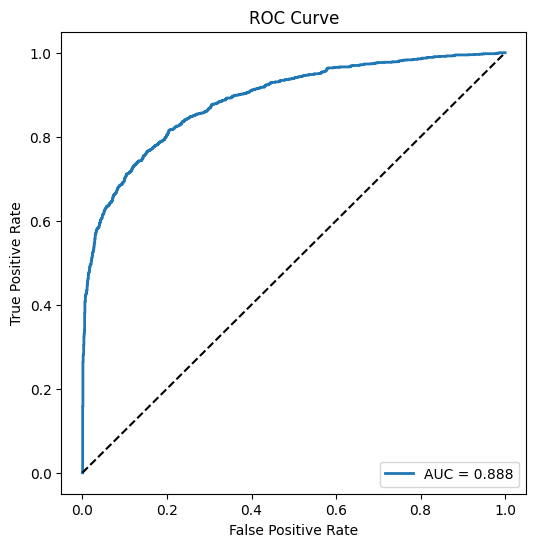

In [25]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9005301668380603


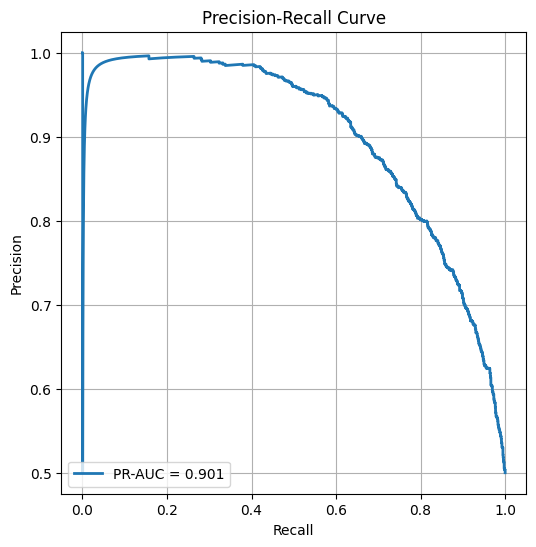

In [26]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

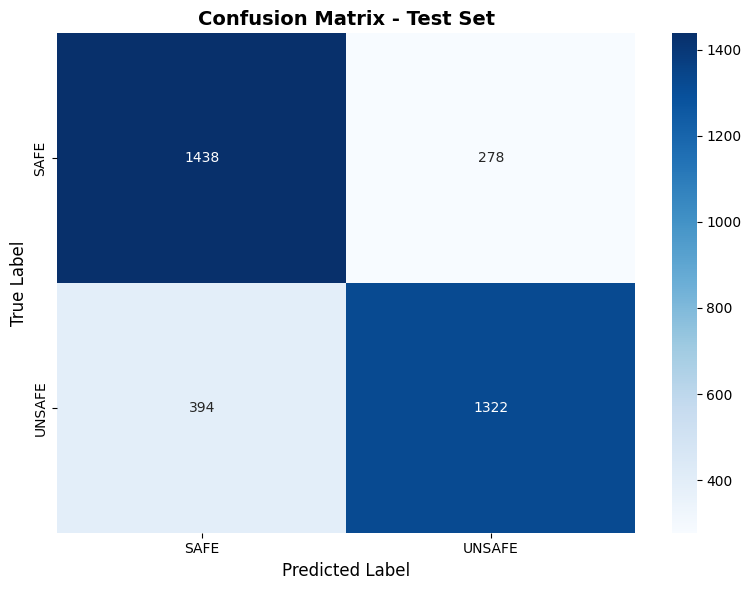

In [31]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
artifact_dir = Path("lstm_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_lstm.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"
params_path = artifact_dir / "best_hyperparams.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)
with open(params_path, "w", encoding="utf-8") as params_file:
    json.dump(best_params, params_file, indent=2)

print("Artifacts saved:")
print(f"  Model: {model_path}")
print(f"  Vocab: {vocab_path}")
print(f"  Best hyperparameters: {params_path}")

Artifacts saved:
  Model: lstm_artifacts\lyrics_lstm.pt
  Vocab: lstm_artifacts\lyrics_vocab.json
  Best hyperparameters: lstm_artifacts\best_hyperparams.json


In [29]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text("you in the dark")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.06696806102991104, 'prediction': 0}
